In [3]:
# CELL 1: Import Libraries and Setup (FIXED)
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import joblib
import warnings
import sklearn
warnings.filterwarnings('ignore')

from sklearn.datasets import load_wine
from sklearn.model_selection import train_test_split, cross_val_score, GridSearchCV, StratifiedKFold
from sklearn.preprocessing import StandardScaler, RobustScaler, MinMaxScaler
from sklearn.decomposition import PCA
from sklearn.feature_selection import SelectKBest, f_classif, RFE, mutual_info_classif
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier, AdaBoostClassifier, ExtraTreesClassifier
from sklearn.linear_model import LogisticRegression, RidgeClassifier
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier
from sklearn.naive_bayes import GaussianNB
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import (accuracy_score, precision_score, recall_score, f1_score, 
                             confusion_matrix, classification_report, roc_auc_score, roc_curve)

# Try importing XGBoost (optional)
try:
    from xgboost import XGBClassifier
    XGBOOST_AVAILABLE = True
    print("XGBoost is available")
except ImportError:
    XGBOOST_AVAILABLE = False
    print("XGBoost not installed - will skip XGBoost model")
    print("To install: pip install xgboost")

# Set display options
pd.set_option('display.max_columns', None)
pd.set_option('display.width', None)
sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (12, 6)

print("\nLibraries imported successfully!")
print(f"Scikit-learn version: {sklearn.__version__}")
print(f"NumPy version: {np.__version__}")
print(f"Pandas version: {pd.__version__}")

XGBoost not installed - will skip XGBoost model
To install: pip install xgboost

Libraries imported successfully!
Scikit-learn version: 1.4.2
NumPy version: 2.2.6
Pandas version: 2.2.3


# Load and Explore Dataset

In [4]:

# Load Wine dataset
data = load_wine()
X = pd.DataFrame(data.data, columns=data.feature_names)
y = pd.Series(data.target, name='wine_class')

# Create full dataframe for exploration
df = X.copy()
df['wine_class'] = y
df['wine_name'] = df['wine_class'].map({0: data.target_names[0], 
                                         1: data.target_names[1], 
                                         2: data.target_names[2]})

print("="*70)
print("DATASET OVERVIEW")
print("="*70)
print(f"\nDataset Shape: {df.shape}")
print(f"Number of Features: {X.shape[1]}")
print(f"Number of Samples: {X.shape[0]}")
print(f"\nTarget Classes: {list(data.target_names)}")
print(f"\nClass Distribution:")
print(df['wine_name'].value_counts())
print("\n" + "="*70)
print("FIRST 5 ROWS")
print("="*70)
print(df.head())

print("\n" + "="*70)
print("STATISTICAL SUMMARY")
print("="*70)
print(df.describe())

print("\n" + "="*70)
print("MISSING VALUES CHECK")
print("="*70)
print(df.isnull().sum())
print(f"\nTotal missing values: {df.isnull().sum().sum()}")

print("\n" + "="*70)
print("DATA TYPES")
print("="*70)
print(df.dtypes)

DATASET OVERVIEW

Dataset Shape: (178, 15)
Number of Features: 13
Number of Samples: 178

Target Classes: [np.str_('class_0'), np.str_('class_1'), np.str_('class_2')]

Class Distribution:
wine_name
class_1    71
class_0    59
class_2    48
Name: count, dtype: int64

FIRST 5 ROWS
   alcohol  malic_acid   ash  alcalinity_of_ash  magnesium  total_phenols  \
0    14.23        1.71  2.43               15.6      127.0           2.80   
1    13.20        1.78  2.14               11.2      100.0           2.65   
2    13.16        2.36  2.67               18.6      101.0           2.80   
3    14.37        1.95  2.50               16.8      113.0           3.85   
4    13.24        2.59  2.87               21.0      118.0           2.80   

   flavanoids  nonflavanoid_phenols  proanthocyanins  color_intensity   hue  \
0        3.06                  0.28             2.29             5.64  1.04   
1        2.76                  0.26             1.28             4.38  1.05   
2        3.24       

# CELL 3: Exploratory Data Analysis - Visualizations


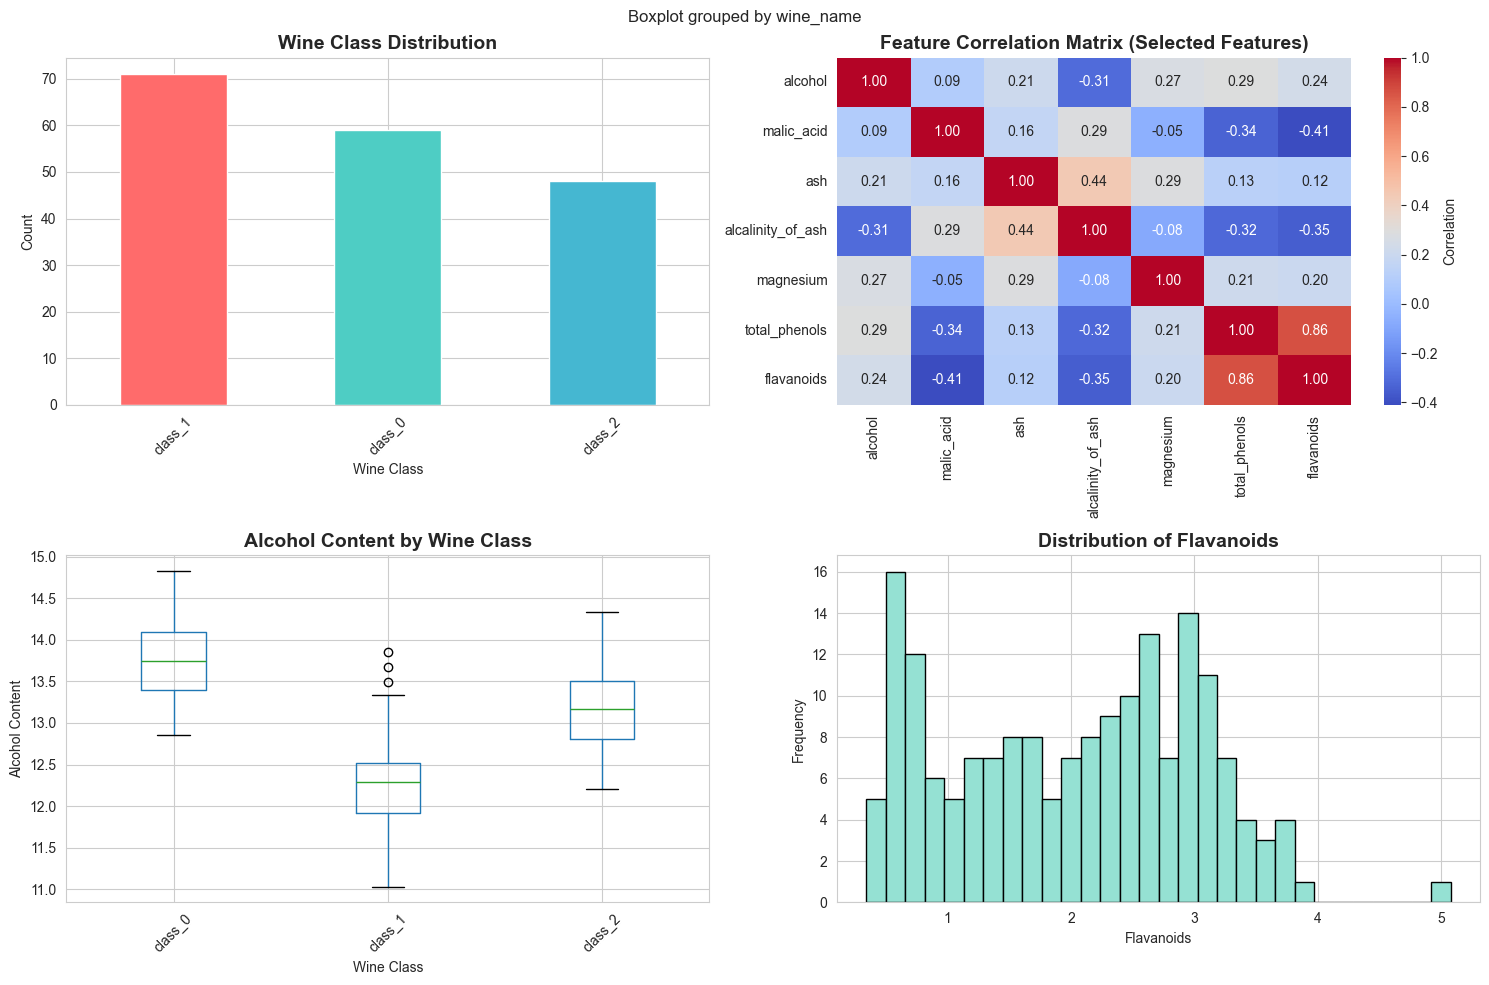

Visualizations completed!


In [5]:
fig, axes = plt.subplots(2, 2, figsize=(15, 10))

# Class distribution
df['wine_name'].value_counts().plot(kind='bar', ax=axes[0, 0], color=['#FF6B6B', '#4ECDC4', '#45B7D1'])
axes[0, 0].set_title('Wine Class Distribution', fontsize=14, fontweight='bold')
axes[0, 0].set_xlabel('Wine Class')
axes[0, 0].set_ylabel('Count')
axes[0, 0].tick_params(axis='x', rotation=45)

# Correlation heatmap (top features)
correlation_matrix = df[X.columns[:7]].corr()
sns.heatmap(correlation_matrix, annot=True, fmt='.2f', cmap='coolwarm', ax=axes[0, 1], 
            cbar_kws={'label': 'Correlation'})
axes[0, 1].set_title('Feature Correlation Matrix (Selected Features)', fontsize=14, fontweight='bold')

# Box plot for one feature across classes
df.boxplot(column='alcohol', by='wine_name', ax=axes[1, 0])
axes[1, 0].set_title('Alcohol Content by Wine Class', fontsize=14, fontweight='bold')
axes[1, 0].set_xlabel('Wine Class')
axes[1, 0].set_ylabel('Alcohol Content')
plt.sca(axes[1, 0])
plt.xticks(rotation=45)

# Feature distributions
df['flavanoids'].hist(bins=30, ax=axes[1, 1], color='#95E1D3', edgecolor='black')
axes[1, 1].set_title('Distribution of Flavanoids', fontsize=14, fontweight='bold')
axes[1, 1].set_xlabel('Flavanoids')
axes[1, 1].set_ylabel('Frequency')

plt.tight_layout()
plt.show()

print("Visualizations completed!")

# CELL 4: Additional EDA - Pairplot for Selected Features

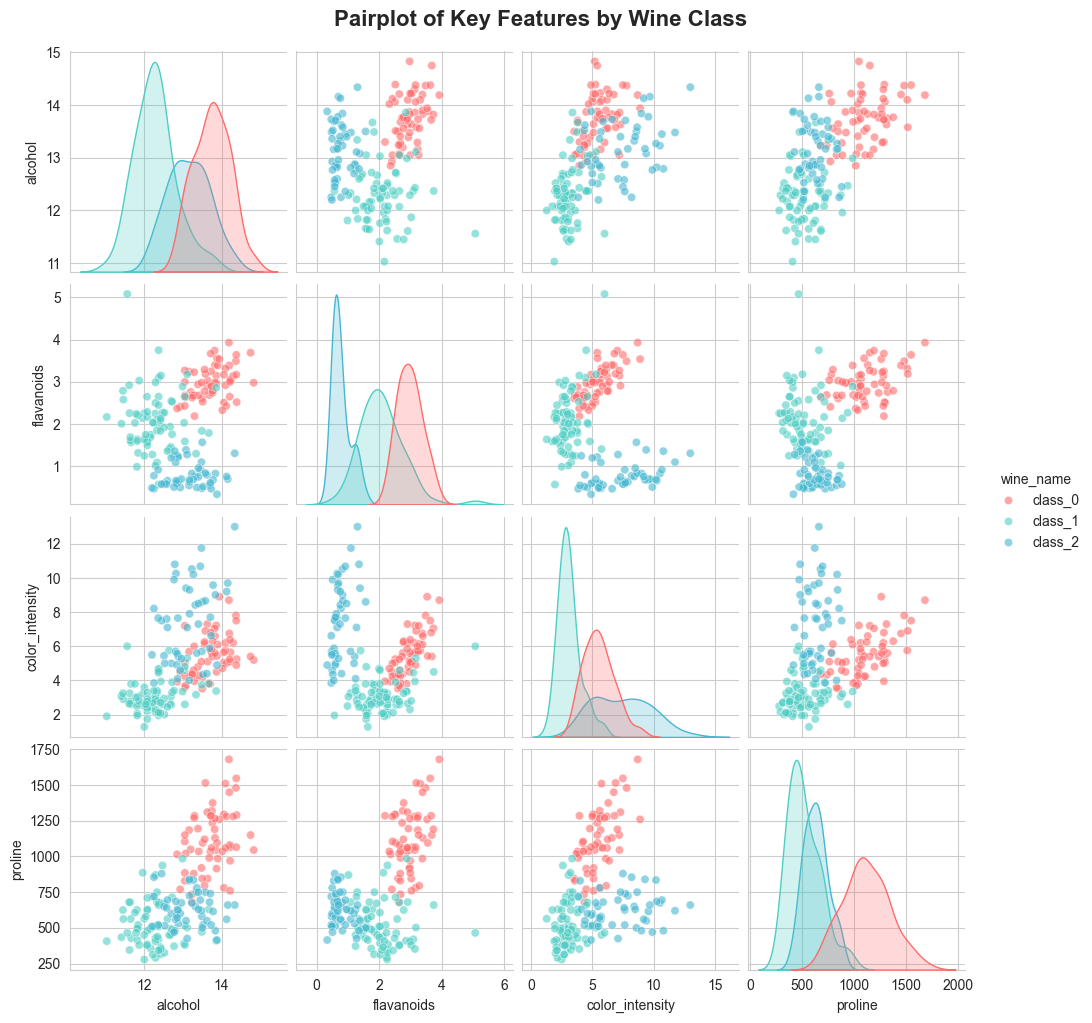

Pairplot visualization completed!


In [6]:
# Select most important features for visualization
selected_features = ['alcohol', 'flavanoids', 'color_intensity', 'proline']
plot_df = df[selected_features + ['wine_name']]

pairplot = sns.pairplot(plot_df, hue='wine_name', palette={'class_0': '#FF6B6B', 
                                                             'class_1': '#4ECDC4', 
                                                             'class_2': '#45B7D1'},
                       plot_kws={'alpha': 0.6}, diag_kind='kde')
pairplot.fig.suptitle('Pairplot of Key Features by Wine Class', y=1.02, fontsize=16, fontweight='bold')
plt.show()

print("Pairplot visualization completed!")

# CELL 5: Data Preprocessing - Handle Missing Values & Outliers

In [7]:
print("="*70)
print("DATA PREPROCESSING")
print("="*70)

# 1. Missing Values Treatment
print("\n1. MISSING VALUES TREATMENT")
print("-"*70)
# Although this dataset has no missing values, we implement robust handling
X_processed = X.copy()

# Check for missing values
missing_before = X_processed.isnull().sum().sum()
print(f"Missing values before treatment: {missing_before}")

# Fill missing values with median (robust to outliers)
for col in X_processed.columns:
    if X_processed[col].isnull().any():
        X_processed[col].fillna(X_processed[col].median(), inplace=True)

missing_after = X_processed.isnull().sum().sum()
print(f"Missing values after treatment: {missing_after}")

# 2. Outlier Detection and Treatment
print("\n2. OUTLIER DETECTION & TREATMENT")
print("-"*70)

def detect_outliers_iqr(df, column):
    """Detect outliers using IQR method"""
    Q1 = df[column].quantile(0.25)
    Q3 = df[column].quantile(0.75)
    IQR = Q3 - Q1
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR
    outliers = df[(df[column] < lower_bound) | (df[column] > upper_bound)]
    return len(outliers)

outlier_counts = {}
for col in X_processed.columns:
    outlier_count = detect_outliers_iqr(X_processed, col)
    if outlier_count > 0:
        outlier_counts[col] = outlier_count

print(f"Features with outliers: {len(outlier_counts)}")
if outlier_counts:
    print("\nOutlier counts by feature:")
    for feature, count in sorted(outlier_counts.items(), key=lambda x: x[1], reverse=True)[:5]:
        print(f"  {feature}: {count} outliers")

# We'll handle outliers using RobustScaler later
print("\nNote: Outliers will be handled using RobustScaler during feature scaling")

print("\n" + "="*70)

DATA PREPROCESSING

1. MISSING VALUES TREATMENT
----------------------------------------------------------------------
Missing values before treatment: 0
Missing values after treatment: 0

2. OUTLIER DETECTION & TREATMENT
----------------------------------------------------------------------
Features with outliers: 7

Outlier counts by feature:
  alcalinity_of_ash: 4 outliers
  magnesium: 4 outliers
  color_intensity: 4 outliers
  malic_acid: 3 outliers
  ash: 3 outliers

Note: Outliers will be handled using RobustScaler during feature scaling



# CELL 6: Feature Engineering - Create New Features


In [8]:
print("="*70)
print("FEATURE ENGINEERING")
print("="*70)

X_engineered = X_processed.copy()

# 1. Polynomial Features (interaction terms)
print("\n1. CREATING INTERACTION FEATURES")
print("-"*70)
X_engineered['alcohol_x_flavanoids'] = X_engineered['alcohol'] * X_engineered['flavanoids']
X_engineered['alcohol_x_proline'] = X_engineered['alcohol'] * X_engineered['proline']
X_engineered['color_intensity_x_hue'] = X_engineered['color_intensity'] * X_engineered['hue']
X_engineered['phenols_x_flavanoids'] = X_engineered['total_phenols'] * X_engineered['flavanoids']

# 2. Ratio Features
print("Creating ratio features...")
X_engineered['phenols_flavanoids_ratio'] = X_engineered['total_phenols'] / (X_engineered['flavanoids'] + 1e-5)
X_engineered['alcohol_acid_ratio'] = X_engineered['alcohol'] / (X_engineered['malic_acid'] + 1e-5)
X_engineered['ash_alkalinity_ratio'] = X_engineered['ash'] / (X_engineered['alcalinity_of_ash'] + 1e-5)

# 3. Aggregate Features
print("Creating aggregate features...")
X_engineered['total_chemical_sum'] = X_engineered[['malic_acid', 'ash', 'alcalinity_of_ash', 
                                                     'magnesium', 'total_phenols']].sum(axis=1)
X_engineered['phenolic_compounds_sum'] = X_engineered[['total_phenols', 'flavanoids', 
                                                        'nonflavanoid_phenols', 
                                                        'proanthocyanins']].sum(axis=1)

# 4. Binning continuous features
print("Creating binned features...")
X_engineered['alcohol_category'] = pd.cut(X_engineered['alcohol'], bins=3, labels=[0, 1, 2])
X_engineered['proline_category'] = pd.cut(X_engineered['proline'], bins=3, labels=[0, 1, 2])

print(f"\nOriginal feature count: {X_processed.shape[1]}")
print(f"Engineered feature count: {X_engineered.shape[1]}")
print(f"New features added: {X_engineered.shape[1] - X_processed.shape[1]}")

print("\nNew features created:")
new_features = [col for col in X_engineered.columns if col not in X_processed.columns]
for i, feat in enumerate(new_features, 1):
    print(f"  {i}. {feat}")

print("\n" + "="*70)

FEATURE ENGINEERING

1. CREATING INTERACTION FEATURES
----------------------------------------------------------------------
Creating ratio features...
Creating aggregate features...
Creating binned features...

Original feature count: 13
Engineered feature count: 24
New features added: 11

New features created:
  1. alcohol_x_flavanoids
  2. alcohol_x_proline
  3. color_intensity_x_hue
  4. phenols_x_flavanoids
  5. phenols_flavanoids_ratio
  6. alcohol_acid_ratio
  7. ash_alkalinity_ratio
  8. total_chemical_sum
  9. phenolic_compounds_sum
  10. alcohol_category
  11. proline_category



# CELL 7: Train-Test Split

In [9]:
print("="*70)
print("TRAIN-TEST SPLIT")
print("="*70)

# Split data with stratification
X_train, X_test, y_train, y_test = train_test_split(
    X_engineered, y, 
    test_size=0.2, 
    random_state=42, 
    stratify=y
)

print(f"\nTraining set size: {X_train.shape[0]} samples ({X_train.shape[0]/len(X_engineered)*100:.1f}%)")
print(f"Test set size: {X_test.shape[0]} samples ({X_test.shape[0]/len(X_engineered)*100:.1f}%)")

print("\nClass distribution in training set:")
print(y_train.value_counts().sort_index())

print("\nClass distribution in test set:")
print(y_test.value_counts().sort_index())

print("\n" + "="*70)

TRAIN-TEST SPLIT

Training set size: 142 samples (79.8%)
Test set size: 36 samples (20.2%)

Class distribution in training set:
wine_class
0    47
1    57
2    38
Name: count, dtype: int64

Class distribution in test set:
wine_class
0    12
1    14
2    10
Name: count, dtype: int64



# CELL 8: Feature Scaling Comparison


In [10]:
print("="*70)
print("FEATURE SCALING COMPARISON")
print("="*70)

# Compare different scalers
scalers = {
    'StandardScaler': StandardScaler(),
    'RobustScaler': RobustScaler(),
    'MinMaxScaler': MinMaxScaler()
}

scaler_results = {}

# Simple test with Logistic Regression
for scaler_name, scaler in scalers.items():
    X_train_scaled = scaler.fit_transform(X_train)
    X_test_scaled = scaler.transform(X_test)
    
    # Quick test with LogisticRegression
    lr = LogisticRegression(max_iter=2000, random_state=42)
    lr.fit(X_train_scaled, y_train)
    score = lr.score(X_test_scaled, y_test)
    scaler_results[scaler_name] = score
    print(f"{scaler_name}: Accuracy = {score:.4f}")

# Select best scaler
best_scaler_name = max(scaler_results, key=scaler_results.get)
print(f"\nBest scaler: {best_scaler_name} with accuracy {scaler_results[best_scaler_name]:.4f}")

# Use best scaler for further processing
best_scaler = scalers[best_scaler_name]
X_train_scaled = best_scaler.fit_transform(X_train)
X_test_scaled = best_scaler.transform(X_test)

print("\n" + "="*70)

FEATURE SCALING COMPARISON
StandardScaler: Accuracy = 0.9722
RobustScaler: Accuracy = 0.9722
MinMaxScaler: Accuracy = 0.9722

Best scaler: StandardScaler with accuracy 0.9722



# CELL 9: Feature Selection - Method 1: Statistical Methods


FEATURE SELECTION - STATISTICAL METHODS

1. ANOVA F-STATISTIC (SelectKBest)
----------------------------------------------------------------------

Top 10 features by F-statistic:
                     Feature    F_Score
        alcohol_x_flavanoids 246.491316
                  flavanoids 224.760551
           alcohol_x_proline 192.194567
                     proline 161.459538
od280/od315_of_diluted_wines 144.758527
        phenols_x_flavanoids 141.845207
    phenols_flavanoids_ratio 132.940233
      phenolic_compounds_sum 117.328517
            proline_category 114.249280
             color_intensity 103.897340

2. MUTUAL INFORMATION
----------------------------------------------------------------------

Top 10 features by Mutual Information:
                     Feature  MI_Score
        alcohol_x_flavanoids  0.686131
                  flavanoids  0.674179
        phenols_x_flavanoids  0.617765
             color_intensity  0.616539
                     proline  0.536724
           a

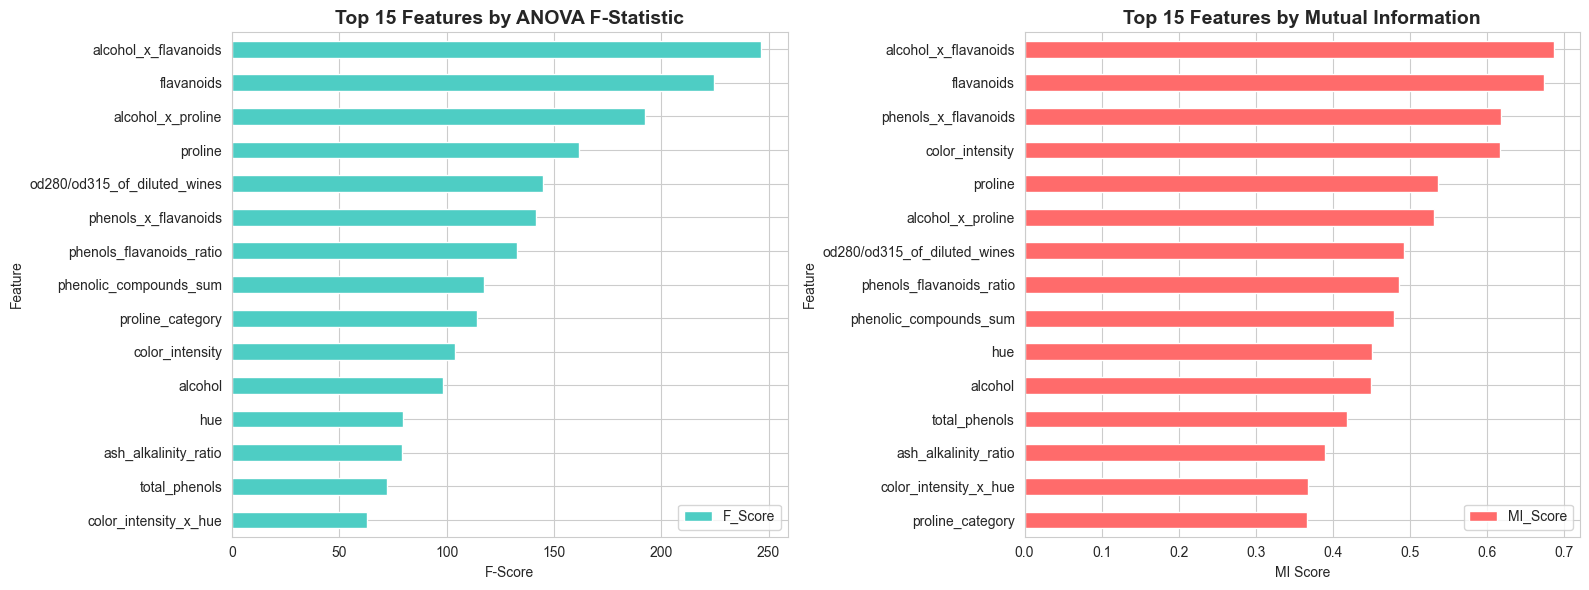

In [11]:
print("="*70)
print("FEATURE SELECTION - STATISTICAL METHODS")
print("="*70)

# 1. SelectKBest with f_classif
print("\n1. ANOVA F-STATISTIC (SelectKBest)")
print("-"*70)
k_best = SelectKBest(score_func=f_classif, k=10)
k_best.fit(X_train_scaled, y_train)

# Get feature scores
feature_scores = pd.DataFrame({
    'Feature': X_engineered.columns,
    'F_Score': k_best.scores_
}).sort_values('F_Score', ascending=False)

print("\nTop 10 features by F-statistic:")
print(feature_scores.head(10).to_string(index=False))

# 2. Mutual Information
print("\n2. MUTUAL INFORMATION")
print("-"*70)
mi_scores = mutual_info_classif(X_train_scaled, y_train, random_state=42)
mi_df = pd.DataFrame({
    'Feature': X_engineered.columns,
    'MI_Score': mi_scores
}).sort_values('MI_Score', ascending=False)

print("\nTop 10 features by Mutual Information:")
print(mi_df.head(10).to_string(index=False))

# Visualize feature scores
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

feature_scores.head(15).plot(x='Feature', y='F_Score', kind='barh', ax=axes[0], color='#4ECDC4')
axes[0].set_title('Top 15 Features by ANOVA F-Statistic', fontsize=14, fontweight='bold')
axes[0].set_xlabel('F-Score')
axes[0].invert_yaxis()

mi_df.head(15).plot(x='Feature', y='MI_Score', kind='barh', ax=axes[1], color='#FF6B6B')
axes[1].set_title('Top 15 Features by Mutual Information', fontsize=14, fontweight='bold')
axes[1].set_xlabel('MI Score')
axes[1].invert_yaxis()

plt.tight_layout()
plt.show()

print("\n" + "="*70)

# CELL 10: Feature Selection - Method 2: Tree-based Importance


FEATURE SELECTION - TREE-BASED IMPORTANCE

Top 15 features by Random Forest Importance:
                     Feature  Importance
             color_intensity    0.126057
           alcohol_x_proline    0.094121
                     proline    0.076571
                  flavanoids    0.075949
        alcohol_x_flavanoids    0.067226
od280/od315_of_diluted_wines    0.061894
    phenols_flavanoids_ratio    0.060795
                     alcohol    0.059976
        phenols_x_flavanoids    0.052089
      phenolic_compounds_sum    0.051989
                         hue    0.048795
        ash_alkalinity_ratio    0.046525
       color_intensity_x_hue    0.043522
            proline_category    0.035897
               total_phenols    0.017035


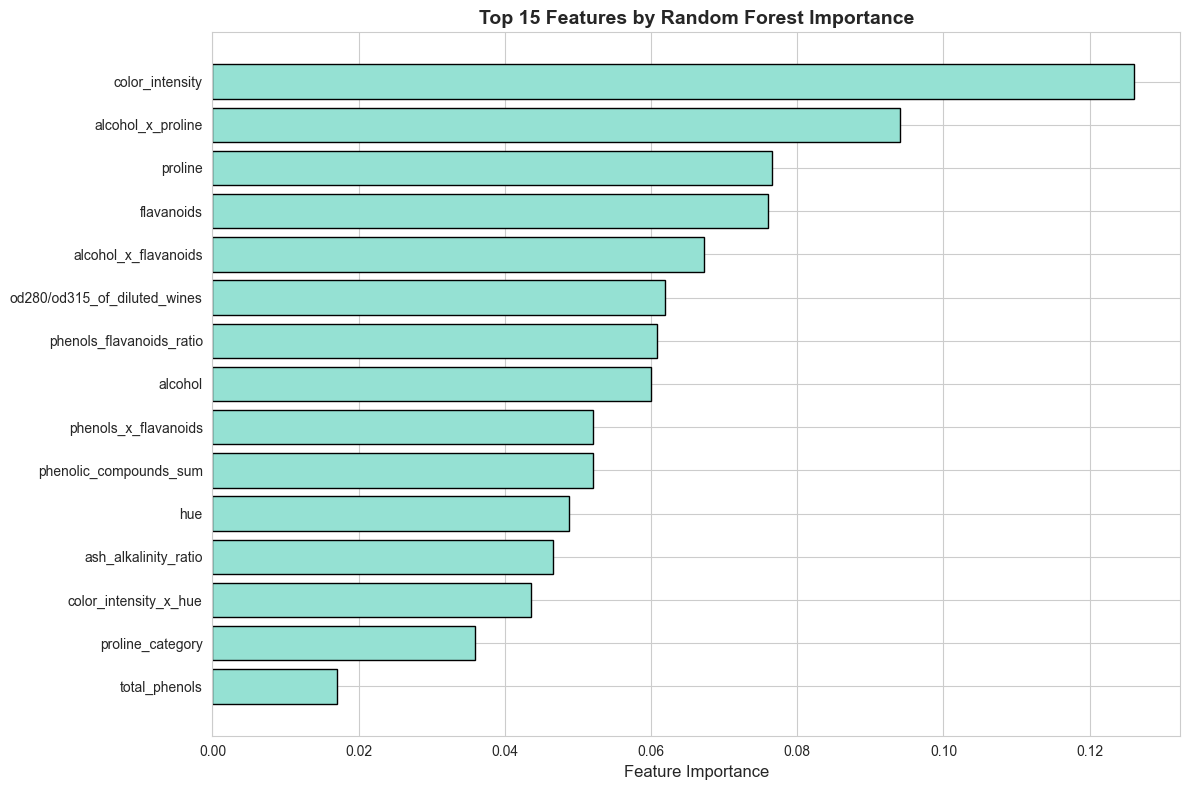

In [12]:
print("="*70)
print("FEATURE SELECTION - TREE-BASED IMPORTANCE")
print("="*70)

# Random Forest Feature Importance
rf_selector = RandomForestClassifier(n_estimators=300, random_state=42, n_jobs=-1)
rf_selector.fit(X_train_scaled, y_train)

rf_importance = pd.DataFrame({
    'Feature': X_engineered.columns,
    'Importance': rf_selector.feature_importances_
}).sort_values('Importance', ascending=False)

print("\nTop 15 features by Random Forest Importance:")
print(rf_importance.head(15).to_string(index=False))

# Visualize
plt.figure(figsize=(12, 8))
plt.barh(range(15), rf_importance.head(15)['Importance'].values, color='#95E1D3', edgecolor='black')
plt.yticks(range(15), rf_importance.head(15)['Feature'].values)
plt.xlabel('Feature Importance', fontsize=12)
plt.title('Top 15 Features by Random Forest Importance', fontsize=14, fontweight='bold')
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()

print("\n" + "="*70)

# CELL 11: Feature Selection - Method 3: Recursive Feature Elimination (RFE)


In [13]:
print("="*70)
print("FEATURE SELECTION - RECURSIVE FEATURE ELIMINATION (RFE)")
print("="*70)

# Use Logistic Regression as the estimator for RFE
rfe_estimator = LogisticRegression(max_iter=2000, random_state=42)
rfe = RFE(estimator=rfe_estimator, n_features_to_select=10, step=1)
rfe.fit(X_train_scaled, y_train)

# Get selected features
rfe_support = pd.DataFrame({
    'Feature': X_engineered.columns,
    'Selected': rfe.support_,
    'Ranking': rfe.ranking_
}).sort_values('Ranking')

print("\nRFE Selected Features (Top 10):")
selected_rfe = rfe_support[rfe_support['Selected'] == True]
print(selected_rfe['Feature'].tolist())

print("\nRFE Feature Rankings:")
print(rfe_support.head(15).to_string(index=False))

print("\n" + "="*70)

FEATURE SELECTION - RECURSIVE FEATURE ELIMINATION (RFE)

RFE Selected Features (Top 10):
['alcohol', 'od280/od315_of_diluted_wines', 'alcohol_x_flavanoids', 'alcohol_x_proline', 'proline', 'color_intensity', 'hue', 'phenols_flavanoids_ratio', 'alcohol_acid_ratio', 'ash_alkalinity_ratio']

RFE Feature Rankings:
                     Feature  Selected  Ranking
                     alcohol      True        1
od280/od315_of_diluted_wines      True        1
        alcohol_x_flavanoids      True        1
           alcohol_x_proline      True        1
                     proline      True        1
             color_intensity      True        1
                         hue      True        1
    phenols_flavanoids_ratio      True        1
          alcohol_acid_ratio      True        1
        ash_alkalinity_ratio      True        1
      phenolic_compounds_sum     False        2
                         ash     False        3
           alcalinity_of_ash     False        4
                

# CELL 12: Select Final Features - Ensemble Approach


In [14]:
print("="*70)
print("FINAL FEATURE SELECTION - ENSEMBLE APPROACH")
print("="*70)

# Combine rankings from different methods
top_k_best = set(feature_scores.head(10)['Feature'].values)
top_mi = set(mi_df.head(10)['Feature'].values)
top_rf = set(rf_importance.head(10)['Feature'].values)
top_rfe = set(rfe_support[rfe_support['Selected']]['Feature'].values)

# Features that appear in at least 2 methods
all_features = top_k_best | top_mi | top_rf | top_rfe
feature_vote_count = {}

for feature in all_features:
    count = 0
    if feature in top_k_best:
        count += 1
    if feature in top_mi:
        count += 1
    if feature in top_rf:
        count += 1
    if feature in top_rfe:
        count += 1
    feature_vote_count[feature] = count

# Sort by vote count
feature_votes_df = pd.DataFrame(list(feature_vote_count.items()), 
                                 columns=['Feature', 'Vote_Count']).sort_values('Vote_Count', ascending=False)

print("\nFeature Voting Results:")
print(feature_votes_df.head(20).to_string(index=False))

# Select features with at least 2 votes
selected_features = feature_votes_df[feature_votes_df['Vote_Count'] >= 2]['Feature'].tolist()

print(f"\nFeatures selected (appeared in ≥2 methods): {len(selected_features)}")
print("\nFinal Selected Features:")
for i, feat in enumerate(selected_features, 1):
    votes = feature_vote_count[feat]
    print(f"  {i}. {feat} (votes: {votes})")

# Create datasets with selected features
X_train_selected = X_train[selected_features]
X_test_selected = X_test[selected_features]

# Scale selected features
X_train_final = best_scaler.fit_transform(X_train_selected)
X_test_final = best_scaler.transform(X_test_selected)

print(f"\nFinal dataset shape: {X_train_final.shape}")
print("\n" + "="*70)

FINAL FEATURE SELECTION - ENSEMBLE APPROACH

Feature Voting Results:
                     Feature  Vote_Count
        alcohol_x_flavanoids           4
             color_intensity           4
    phenols_flavanoids_ratio           4
od280/od315_of_diluted_wines           4
           alcohol_x_proline           4
                     proline           4
                  flavanoids           3
        phenols_x_flavanoids           3
      phenolic_compounds_sum           3
                     alcohol           2
                         hue           2
        ash_alkalinity_ratio           1
            proline_category           1
          alcohol_acid_ratio           1

Features selected (appeared in ≥2 methods): 11

Final Selected Features:
  1. alcohol_x_flavanoids (votes: 4)
  2. color_intensity (votes: 4)
  3. phenols_flavanoids_ratio (votes: 4)
  4. od280/od315_of_diluted_wines (votes: 4)
  5. alcohol_x_proline (votes: 4)
  6. proline (votes: 4)
  7. flavanoids (votes: 3)
  

# CELL 13: Dimensionality Reduction - PCA Analysis

DIMENSIONALITY REDUCTION - PCA ANALYSIS

Explained Variance by Component:
PC1: 0.5746 (Cumulative: 0.5746)
PC2: 0.2365 (Cumulative: 0.8111)
PC3: 0.0712 (Cumulative: 0.8822)
PC4: 0.0343 (Cumulative: 0.9165)
PC5: 0.0325 (Cumulative: 0.9491)
PC6: 0.0277 (Cumulative: 0.9768)
PC7: 0.0178 (Cumulative: 0.9946)
PC8: 0.0042 (Cumulative: 0.9987)
PC9: 0.0011 (Cumulative: 0.9998)
PC10: 0.0001 (Cumulative: 0.9999)

Components needed for 95% variance: 6


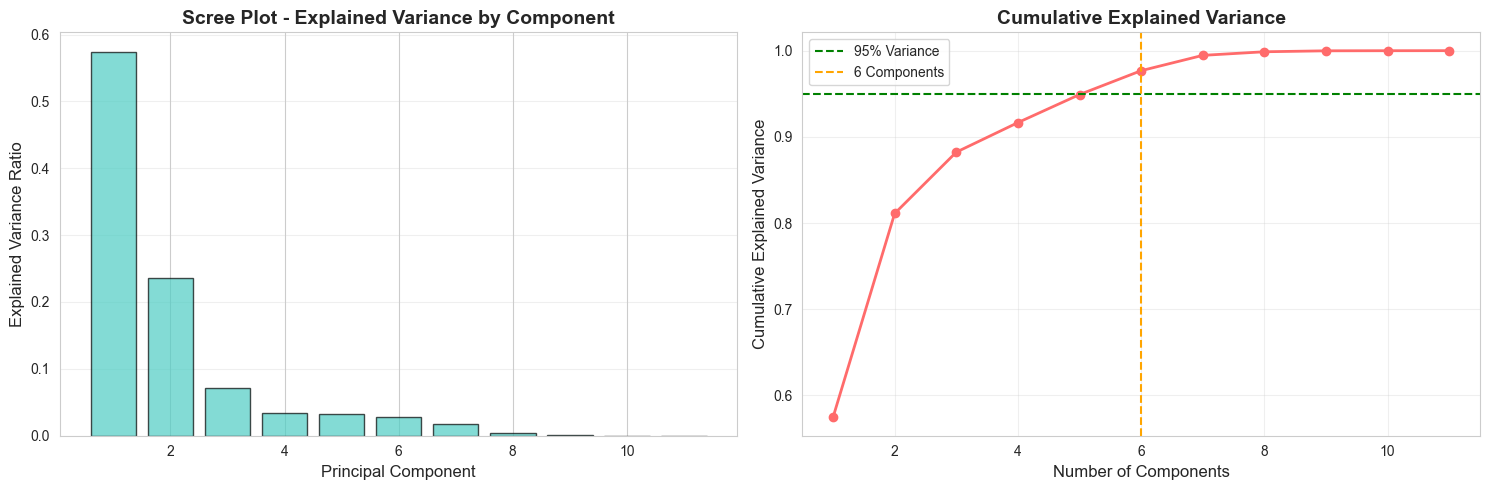


Original shape: (142, 11)
PCA-reduced shape: (142, 6)
Dimensionality reduction: 11 → 6



In [15]:
print("="*70)
print("DIMENSIONALITY REDUCTION - PCA ANALYSIS")
print("="*70)

# Apply PCA
pca = PCA(random_state=42)
X_train_pca = pca.fit_transform(X_train_final)
X_test_pca = pca.transform(X_test_final)

# Explained variance
explained_variance_ratio = pca.explained_variance_ratio_
cumulative_variance_ratio = np.cumsum(explained_variance_ratio)

print("\nExplained Variance by Component:")
for i, (var, cum_var) in enumerate(zip(explained_variance_ratio[:10], cumulative_variance_ratio[:10]), 1):
    print(f"PC{i}: {var:.4f} (Cumulative: {cum_var:.4f})")

# Find number of components for 95% variance
n_components_95 = np.argmax(cumulative_variance_ratio >= 0.95) + 1
print(f"\nComponents needed for 95% variance: {n_components_95}")

# Visualize
fig, axes = plt.subplots(1, 2, figsize=(15, 5))

# Scree plot
axes[0].bar(range(1, len(explained_variance_ratio[:15])+1), explained_variance_ratio[:15], 
            color='#4ECDC4', edgecolor='black', alpha=0.7)
axes[0].set_xlabel('Principal Component', fontsize=12)
axes[0].set_ylabel('Explained Variance Ratio', fontsize=12)
axes[0].set_title('Scree Plot - Explained Variance by Component', fontsize=14, fontweight='bold')
axes[0].grid(axis='y', alpha=0.3)

# Cumulative variance
axes[1].plot(range(1, len(cumulative_variance_ratio)+1), cumulative_variance_ratio, 
             marker='o', linestyle='-', color='#FF6B6B', linewidth=2, markersize=6)
axes[1].axhline(y=0.95, color='green', linestyle='--', label='95% Variance')
axes[1].axvline(x=n_components_95, color='orange', linestyle='--', label=f'{n_components_95} Components')
axes[1].set_xlabel('Number of Components', fontsize=12)
axes[1].set_ylabel('Cumulative Explained Variance', fontsize=12)
axes[1].set_title('Cumulative Explained Variance', fontsize=14, fontweight='bold')
axes[1].legend()
axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.show()

# Create PCA-reduced dataset
pca_optimal = PCA(n_components=n_components_95, random_state=42)
X_train_pca_reduced = pca_optimal.fit_transform(X_train_final)
X_test_pca_reduced = pca_optimal.transform(X_test_final)

print(f"\nOriginal shape: {X_train_final.shape}")
print(f"PCA-reduced shape: {X_train_pca_reduced.shape}")
print(f"Dimensionality reduction: {X_train_final.shape[1]} → {X_train_pca_reduced.shape[1]}")

print("\n" + "="*70)

# CELL 14: Model Training - Multiple Algorithms (UPDATED)

MODEL TRAINING - MULTIPLE ALGORITHMS

XGBoost not available - proceeding with other models

Training 11 models...

Training Logistic Regression...
Training Random Forest...
Training Gradient Boosting...
Training Extra Trees...
Training AdaBoost...
Training SVM (RBF)...
Training SVM (Linear)...
Training K-Nearest Neighbors...
Training Naive Bayes...
Training Ridge Classifier...
Training Decision Tree...

MODEL PERFORMANCE COMPARISON

               Model  Accuracy  Precision   Recall  F1-Score  ROC-AUC
Logistic Regression  1.000000   1.000000 1.000000  1.000000 1.000000
      Random Forest  1.000000   1.000000 1.000000  1.000000 1.000000
  Gradient Boosting  1.000000   1.000000 1.000000  1.000000 1.000000
        Extra Trees  1.000000   1.000000 1.000000  1.000000 1.000000
          SVM (RBF)  0.972222   0.974074 0.972222  0.971970 1.000000
   Ridge Classifier  0.972222   0.974074 0.972222  0.971970      NaN
K-Nearest Neighbors  0.972222   0.974359 0.972222  0.972263 0.999369
      Deci

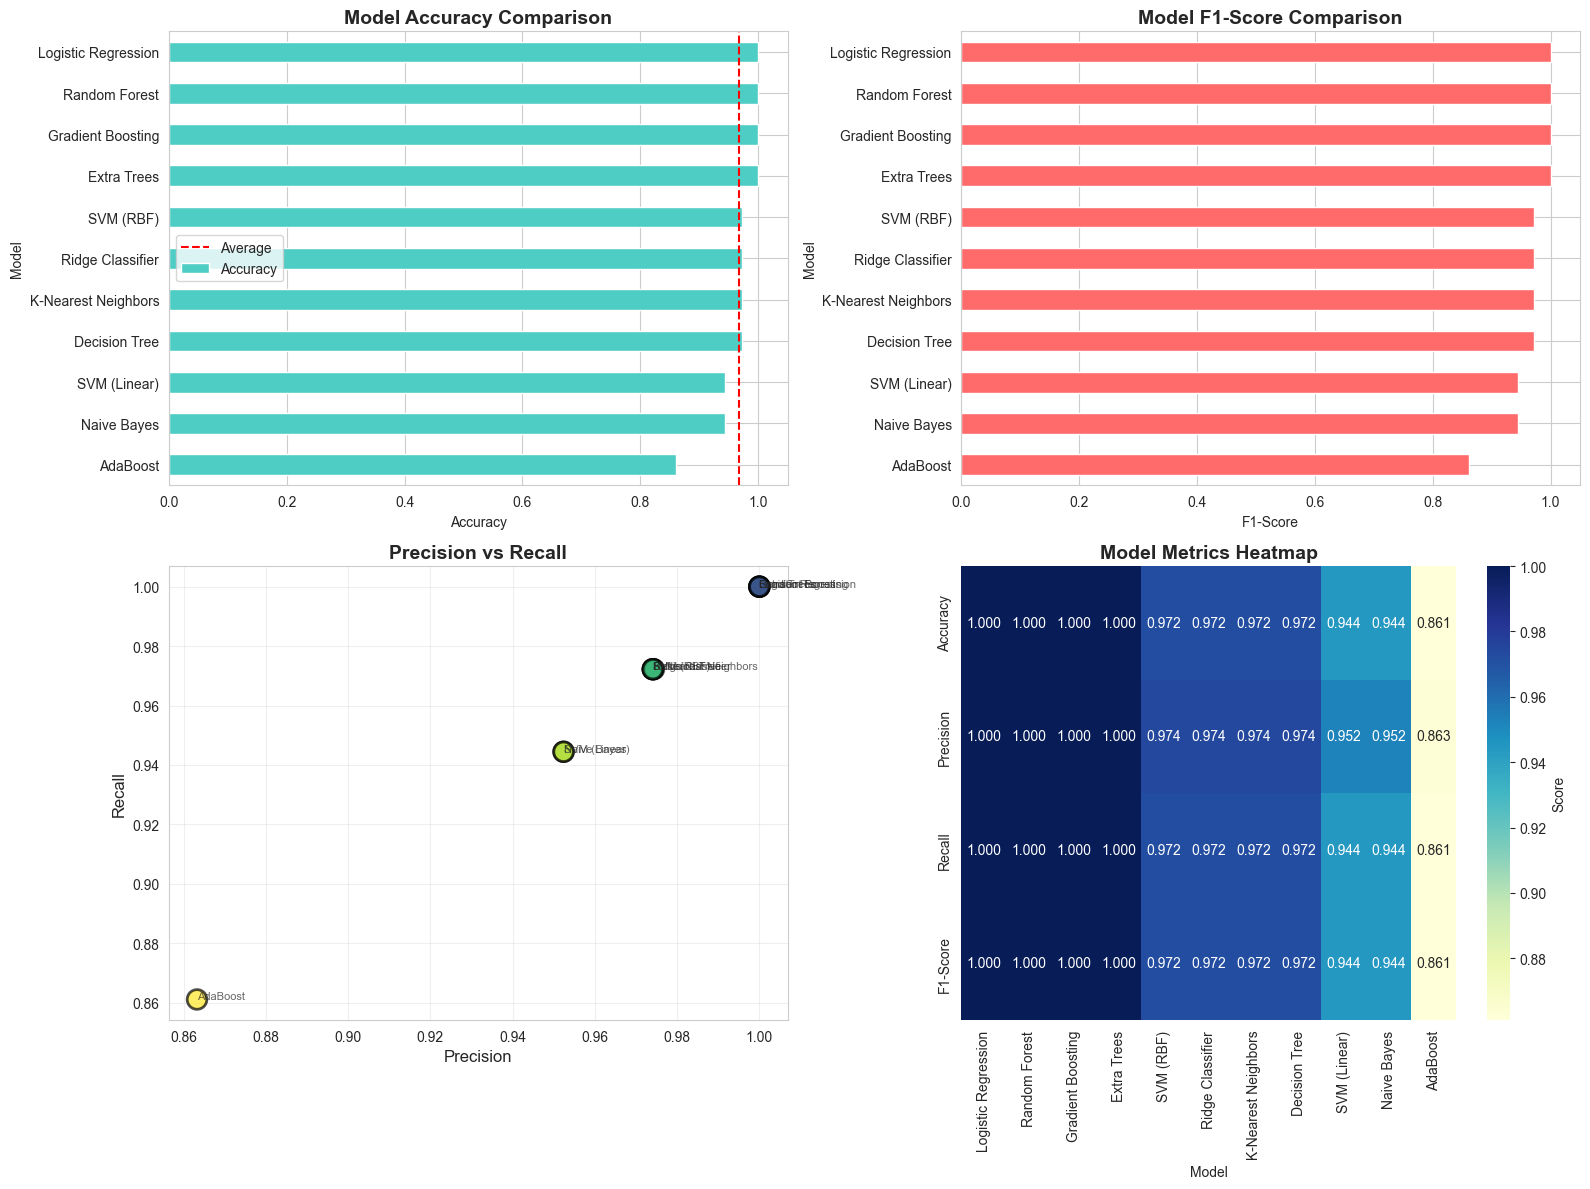

In [17]:
print("="*70)
print("MODEL TRAINING - MULTIPLE ALGORITHMS")
print("="*70)

# Define models to compare
models = {
    'Logistic Regression': LogisticRegression(max_iter=2000, random_state=42),
    'Random Forest': RandomForestClassifier(n_estimators=200, random_state=42, n_jobs=-1),
    'Gradient Boosting': GradientBoostingClassifier(n_estimators=200, random_state=42),
    'Extra Trees': ExtraTreesClassifier(n_estimators=200, random_state=42, n_jobs=-1),
    'AdaBoost': AdaBoostClassifier(n_estimators=100, random_state=42),
    'SVM (RBF)': SVC(kernel='rbf', probability=True, random_state=42),
    'SVM (Linear)': SVC(kernel='linear', probability=True, random_state=42),
    'K-Nearest Neighbors': KNeighborsClassifier(n_neighbors=5),
    'Naive Bayes': GaussianNB(),
    'Ridge Classifier': RidgeClassifier(random_state=42),
    'Decision Tree': DecisionTreeClassifier(random_state=42, max_depth=10)
}

# Add XGBoost if available
if XGBOOST_AVAILABLE:
    models['XGBoost'] = XGBClassifier(n_estimators=200, random_state=42, eval_metric='mlogloss', use_label_encoder=False)
    print("\nXGBoost included in model comparison")
else:
    print("\nXGBoost not available - proceeding with other models")

# Train and evaluate each model
results = []

print(f"\nTraining {len(models)} models...\n")

for name, model in models.items():
    print(f"Training {name}...")
    
    # Train on full selected features
    model.fit(X_train_final, y_train)
    y_pred = model.predict(X_test_final)
    y_pred_proba = model.predict_proba(X_test_final) if hasattr(model, 'predict_proba') else None
    
    # Calculate metrics
    accuracy = accuracy_score(y_test, y_pred)
    precision = precision_score(y_test, y_pred, average='weighted')
    recall = recall_score(y_test, y_pred, average='weighted')
    f1 = f1_score(y_test, y_pred, average='weighted')
    
    # ROC AUC (multi-class)
    if y_pred_proba is not None:
        roc_auc = roc_auc_score(y_test, y_pred_proba, multi_class='ovr', average='weighted')
    else:
        roc_auc = np.nan
    
    results.append({
        'Model': name,
        'Accuracy': accuracy,
        'Precision': precision,
        'Recall': recall,
        'F1-Score': f1,
        'ROC-AUC': roc_auc,
        'Model_Object': model
    })

# Create results dataframe
results_df = pd.DataFrame(results).sort_values('Accuracy', ascending=False)

print("\n" + "="*70)
print("MODEL PERFORMANCE COMPARISON")
print("="*70)
print("\n", results_df[['Model', 'Accuracy', 'Precision', 'Recall', 'F1-Score', 'ROC-AUC']].to_string(index=False))

# Visualize results
fig, axes = plt.subplots(2, 2, figsize=(16, 12))

# Accuracy comparison
results_df.plot(x='Model', y='Accuracy', kind='barh', ax=axes[0, 0], color='#4ECDC4', legend=False)
axes[0, 0].set_title('Model Accuracy Comparison', fontsize=14, fontweight='bold')
axes[0, 0].set_xlabel('Accuracy')
axes[0, 0].invert_yaxis()
axes[0, 0].axvline(x=results_df['Accuracy'].mean(), color='red', linestyle='--', label='Average')
axes[0, 0].legend()

# F1-Score comparison
results_df.plot(x='Model', y='F1-Score', kind='barh', ax=axes[0, 1], color='#FF6B6B', legend=False)
axes[0, 1].set_title('Model F1-Score Comparison', fontsize=14, fontweight='bold')
axes[0, 1].set_xlabel('F1-Score')
axes[0, 1].invert_yaxis()

# Precision vs Recall
axes[1, 0].scatter(results_df['Precision'], results_df['Recall'], s=200, c=range(len(results_df)), 
                   cmap='viridis', alpha=0.7, edgecolors='black', linewidth=2)
for i, model in enumerate(results_df['Model']):
    axes[1, 0].annotate(model, (results_df.iloc[i]['Precision'], results_df.iloc[i]['Recall']),
                       fontsize=8, alpha=0.7)
axes[1, 0].set_xlabel('Precision', fontsize=12)
axes[1, 0].set_ylabel('Recall', fontsize=12)
axes[1, 0].set_title('Precision vs Recall', fontsize=14, fontweight='bold')
axes[1, 0].grid(alpha=0.3)

# Metrics heatmap
metrics_for_heatmap = results_df[['Model', 'Accuracy', 'Precision', 'Recall', 'F1-Score']].set_index('Model')
sns.heatmap(metrics_for_heatmap.T, annot=True, fmt='.3f', cmap='YlGnBu', ax=axes[1, 1], 
            cbar_kws={'label': 'Score'})
axes[1, 1].set_title('Model Metrics Heatmap', fontsize=14, fontweight='bold')

plt.tight_layout()
plt.show()

print("\n" + "="*70)

# CELL 15: Cross-Validation for Top 5 Models

CROSS-VALIDATION ANALYSIS - TOP 5 MODELS

Performing 10-Fold Stratified Cross-Validation...

Cross-validating Logistic Regression...
Cross-validating Random Forest...
Cross-validating Gradient Boosting...
Cross-validating Extra Trees...
Cross-validating SVM (RBF)...

CROSS-VALIDATION RESULTS
              Model  CV_Mean   CV_Std   CV_Min  CV_Max
Logistic Regression 0.986190 0.027640 0.928571     1.0
          SVM (RBF) 0.985714 0.042857 0.857143     1.0
        Extra Trees 0.971905 0.046969 0.857143     1.0
      Random Forest 0.965714 0.055566 0.857143     1.0
  Gradient Boosting 0.944762 0.050449 0.866667     1.0


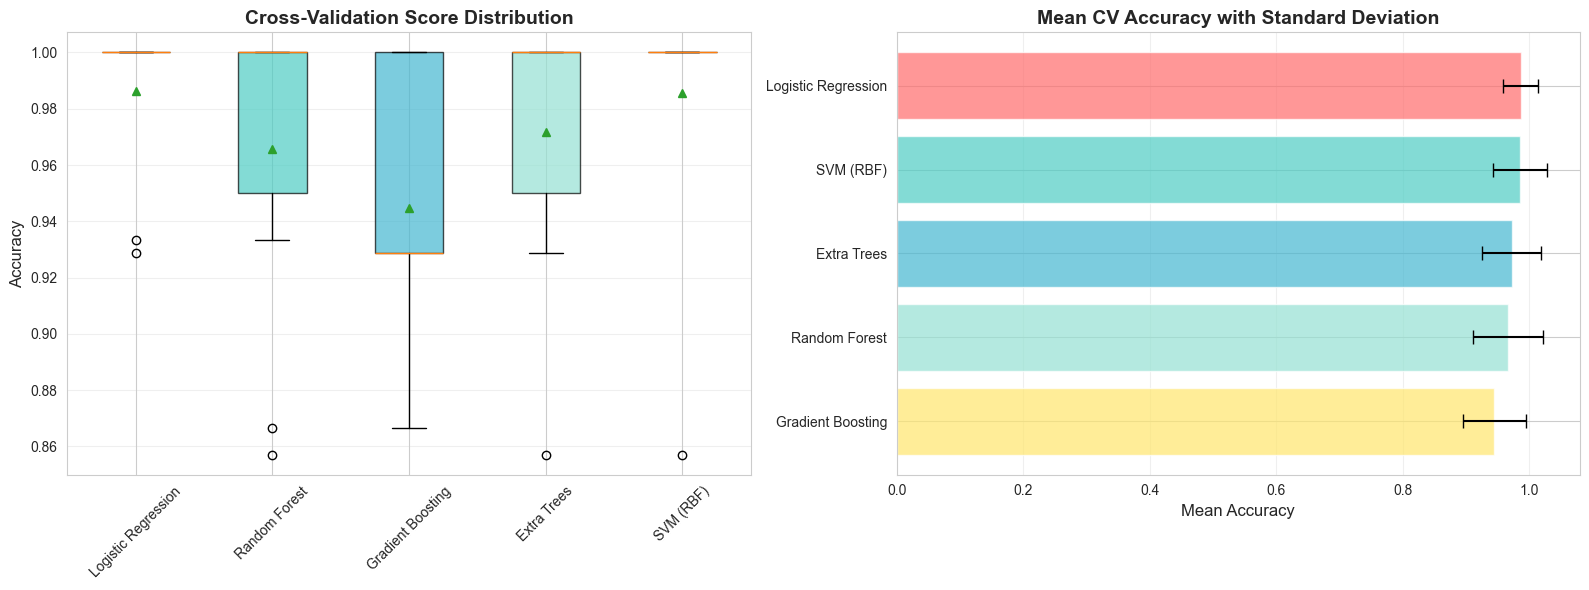

In [18]:
print("="*70)
print("CROSS-VALIDATION ANALYSIS - TOP 5 MODELS")
print("="*70)

# Select top 5 models by accuracy
top_5_models = results_df.head(5)['Model'].tolist()

# Cross-validation setup
cv_strategy = StratifiedKFold(n_splits=10, shuffle=True, random_state=42)
cv_results = []

print("\nPerforming 10-Fold Stratified Cross-Validation...\n")

for model_name in top_5_models:
    model = models[model_name]
    print(f"Cross-validating {model_name}...")
    
    # Perform cross-validation
    cv_scores = cross_val_score(model, X_train_final, y_train, cv=cv_strategy, scoring='accuracy', n_jobs=-1)
    
    cv_results.append({
        'Model': model_name,
        'CV_Mean': cv_scores.mean(),
        'CV_Std': cv_scores.std(),
        'CV_Min': cv_scores.min(),
        'CV_Max': cv_scores.max(),
        'CV_Scores': cv_scores
    })

# Create CV results dataframe
cv_results_df = pd.DataFrame(cv_results).sort_values('CV_Mean', ascending=False)

print("\n" + "="*70)
print("CROSS-VALIDATION RESULTS")
print("="*70)
print(cv_results_df[['Model', 'CV_Mean', 'CV_Std', 'CV_Min', 'CV_Max']].to_string(index=False))

# Visualize CV results
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Box plot of CV scores
cv_scores_data = [result['CV_Scores'] for result in cv_results]
bp = axes[0].boxplot(cv_scores_data, labels=[result['Model'] for result in cv_results],
                      patch_artist=True, showmeans=True)
for patch, color in zip(bp['boxes'], ['#FF6B6B', '#4ECDC4', '#45B7D1', '#95E1D3', '#FFE66D']):
    patch.set_facecolor(color)
    patch.set_alpha(0.7)
axes[0].set_ylabel('Accuracy', fontsize=12)
axes[0].set_title('Cross-Validation Score Distribution', fontsize=14, fontweight='bold')
axes[0].tick_params(axis='x', rotation=45)
axes[0].grid(axis='y', alpha=0.3)

# Mean accuracy with error bars
axes[1].barh(range(len(cv_results_df)), cv_results_df['CV_Mean'], xerr=cv_results_df['CV_Std'],
             color=['#FF6B6B', '#4ECDC4', '#45B7D1', '#95E1D3', '#FFE66D'], alpha=0.7, capsize=5)
axes[1].set_yticks(range(len(cv_results_df)))
axes[1].set_yticklabels(cv_results_df['Model'])
axes[1].set_xlabel('Mean Accuracy', fontsize=12)
axes[1].set_title('Mean CV Accuracy with Standard Deviation', fontsize=14, fontweight='bold')
axes[1].invert_yaxis()
axes[1].grid(axis='x', alpha=0.3)

plt.tight_layout()
plt.show()

print("\n" + "="*70)

# CELL 16: Hyperparameter Tuning - Best Model

In [19]:
print("="*70)
print("HYPERPARAMETER TUNING - GRID SEARCH")
print("="*70)

# Select best model from CV
best_model_name = cv_results_df.iloc[0]['Model']
print(f"\nTuning hyperparameters for: {best_model_name}")

# Define parameter grids for different models
param_grids = {
    'Random Forest': {
        'n_estimators': [100, 200, 300],
        'max_depth': [10, 20, 30, None],
        'min_samples_split': [2, 5, 10],
        'min_samples_leaf': [1, 2, 4],
        'max_features': ['sqrt', 'log2']
    },
    'Gradient Boosting': {
        'n_estimators': [100, 200, 300],
        'learning_rate': [0.01, 0.05, 0.1, 0.2],
        'max_depth': [3, 5, 7],
        'min_samples_split': [2, 5, 10],
        'subsample': [0.8, 0.9, 1.0]
    },
    'Logistic Regression': {
        'C': [0.001, 0.01, 0.1, 1, 10, 100],
        'penalty': ['l2'],
        'solver': ['lbfgs', 'saga']
    },
    'SVM (RBF)': {
        'C': [0.1, 1, 10, 100],
        'gamma': ['scale', 'auto', 0.001, 0.01, 0.1],
        'kernel': ['rbf']
    },
    'Extra Trees': {
        'n_estimators': [100, 200, 300],
        'max_depth': [10, 20, 30, None],
        'min_samples_split': [2, 5, 10],
        'max_features': ['sqrt', 'log2']
    }
}

# Add XGBoost params if available
if XGBOOST_AVAILABLE:
    param_grids['XGBoost'] = {
        'n_estimators': [100, 200, 300],
        'max_depth': [3, 5, 7, 10],
        'learning_rate': [0.01, 0.05, 0.1, 0.2],
        'subsample': [0.7, 0.8, 0.9, 1.0],
        'colsample_bytree': [0.7, 0.8, 0.9, 1.0]
    }

if best_model_name in param_grids:
    param_grid = param_grids[best_model_name]
    
    # Initialize model
    if best_model_name == 'XGBoost' and XGBOOST_AVAILABLE:
        base_model = XGBClassifier(random_state=42, eval_metric='mlogloss', use_label_encoder=False)
    else:
        base_model = models[best_model_name]
    
    # Grid search
    print("\nPerforming Grid Search (this may take a few minutes)...")
    print(f"Parameter grid size: {np.prod([len(v) for v in param_grid.values()])} combinations")
    
    grid_search = GridSearchCV(
        estimator=base_model,
        param_grid=param_grid,
        cv=5,
        scoring='accuracy',
        n_jobs=-1,
        verbose=1
    )
    
    grid_search.fit(X_train_final, y_train)
    
    print("\n" + "="*70)
    print("GRID SEARCH RESULTS")
    print("="*70)
    print(f"\nBest Parameters: {grid_search.best_params_}")
    print(f"Best CV Score: {grid_search.best_score_:.4f}")
    
    # Test best model
    best_tuned_model = grid_search.best_estimator_
    y_pred_tuned = best_tuned_model.predict(X_test_final)
    test_accuracy_tuned = accuracy_score(y_test, y_pred_tuned)
    print(f"Test Accuracy (tuned): {test_accuracy_tuned:.4f}")
    
    # Compare with default
    default_test_acc = results_df[results_df['Model'] == best_model_name]['Accuracy'].values[0]
    print(f"Test Accuracy (default): {default_test_acc:.4f}")
    print(f"Improvement: {(test_accuracy_tuned - default_test_acc):.4f}")
    
else:
    print(f"\nNo predefined parameter grid for {best_model_name}")
    print("Using default parameters from initial training")
    best_tuned_model = results_df[results_df['Model'] == best_model_name]['Model_Object'].values[0]
    test_accuracy_tuned = results_df[results_df['Model'] == best_model_name]['Accuracy'].values[0]

print("\n" + "="*70)

HYPERPARAMETER TUNING - GRID SEARCH

Tuning hyperparameters for: Logistic Regression

Performing Grid Search (this may take a few minutes)...
Parameter grid size: 12 combinations
Fitting 5 folds for each of 12 candidates, totalling 60 fits

GRID SEARCH RESULTS

Best Parameters: {'C': 1, 'penalty': 'l2', 'solver': 'lbfgs'}
Best CV Score: 0.9931
Test Accuracy (tuned): 1.0000
Test Accuracy (default): 1.0000
Improvement: 0.0000



# CELL 17: Final Model Evaluation - Detailed Metrics

FINAL MODEL EVALUATION

CLASSIFICATION REPORT
              precision    recall  f1-score   support

     class_0       1.00      1.00      1.00        12
     class_1       1.00      1.00      1.00        14
     class_2       1.00      1.00      1.00        10

    accuracy                           1.00        36
   macro avg       1.00      1.00      1.00        36
weighted avg       1.00      1.00      1.00        36


CONFUSION MATRIX
[[12  0  0]
 [ 0 14  0]
 [ 0  0 10]]


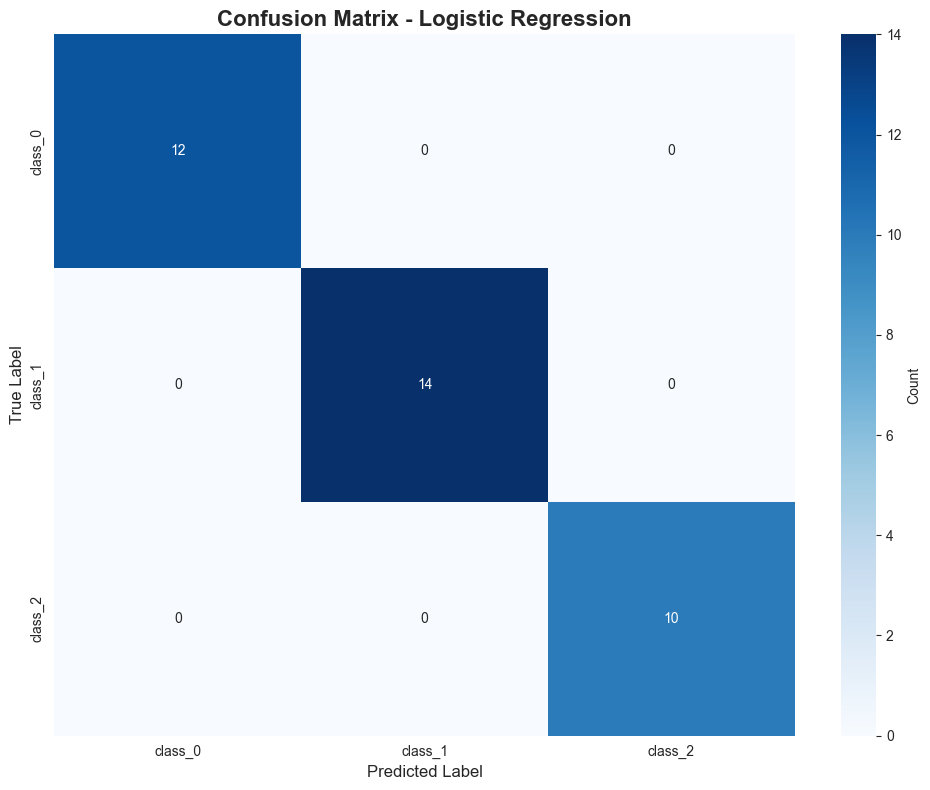


PER-CLASS METRICS
class_0: Accuracy = 1.0000, Support = 12
class_1: Accuracy = 1.0000, Support = 14
class_2: Accuracy = 1.0000, Support = 10



In [20]:
print("="*70)
print("FINAL MODEL EVALUATION")
print("="*70)

# Use best tuned model
final_model = best_tuned_model
y_pred_final = final_model.predict(X_test_final)
y_pred_proba_final = final_model.predict_proba(X_test_final) if hasattr(final_model, 'predict_proba') else None

# Classification Report
print("\n" + "="*70)
print("CLASSIFICATION REPORT")
print("="*70)
print(classification_report(y_test, y_pred_final, target_names=data.target_names))

# Confusion Matrix
cm = confusion_matrix(y_test, y_pred_final)
print("\n" + "="*70)
print("CONFUSION MATRIX")
print("="*70)
print(cm)

# Visualize Confusion Matrix
plt.figure(figsize=(10, 8))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
            xticklabels=data.target_names, 
            yticklabels=data.target_names,
            cbar_kws={'label': 'Count'})
plt.title(f'Confusion Matrix - {best_model_name}', fontsize=16, fontweight='bold')
plt.ylabel('True Label', fontsize=12)
plt.xlabel('Predicted Label', fontsize=12)
plt.tight_layout()
plt.show()

# Per-class metrics
print("\n" + "="*70)
print("PER-CLASS METRICS")
print("="*70)
for i, class_name in enumerate(data.target_names):
    class_mask = (y_test == i)
    class_accuracy = accuracy_score(y_test[class_mask], y_pred_final[class_mask])
    print(f"{class_name}: Accuracy = {class_accuracy:.4f}, Support = {class_mask.sum()}")

print("\n" + "="*70)

# CELL 19: Save Model and Artifacts

In [24]:
import os
import sys

print("="*70)
print("SAVING MODEL AND ARTIFACTS")
print("="*70)

# Separate original and engineered features
original_features = [f for f in selected_features if f in X.columns]
engineered_features = [f for f in selected_features if f not in X.columns]

print(f"\nOriginal features in selection: {len(original_features)}")
print(f"Engineered features in selection: {len(engineered_features)}")

# Prepare artifacts dictionary
artifacts = {
    'model': final_model,
    'scaler': best_scaler,
    'selected_features': selected_features,
    'original_features': original_features,
    'engineered_features': engineered_features,
    'feature_names': list(X_engineered.columns),
    'target_names': list(data.target_names),
    'best_model_name': best_model_name,
    'test_accuracy': test_accuracy_tuned,
    'all_metrics': results_df.to_dict('records'),
    'cv_results': cv_results_df.to_dict('records'),
    'feature_means_original': X[original_features].mean().to_dict() if original_features else {},
    'feature_std_original': X[original_features].std().to_dict() if original_features else {},
    'feature_means_engineered': X_engineered[selected_features].mean().to_dict(),
    'feature_std_engineered': X_engineered[selected_features].std().to_dict(),
    'engineered_features_info': {
        'interaction_features': ['alcohol_x_flavanoids', 'alcohol_x_proline', 
                                 'color_intensity_x_hue', 'phenols_x_flavanoids'],
        'ratio_features': ['phenols_flavanoids_ratio', 'alcohol_acid_ratio', 'ash_alkalinity_ratio'],
        'aggregate_features': ['total_chemical_sum', 'phenolic_compounds_sum'],
        'binned_features': ['alcohol_category', 'proline_category']
    },
    'scaling_method': best_scaler_name,
    'n_classes': len(data.target_names)
}

# Save to file
artifacts_path = './wine_model_artifacts.joblib'
joblib.dump(artifacts, artifacts_path)

print(f"\nModel artifacts saved to: {artifacts_path}")
print(f"File size: {os.path.getsize(artifacts_path) / 1024:.2f} KB")

print("\nArtifacts include:")
print("  ✓ Trained model")
print("  ✓ Feature scaler")
print("  ✓ Selected features list")
print("  ✓ Feature statistics (means & std)")
print("  ✓ Model performance metrics")
print("  ✓ Cross-validation results")
print("  ✓ Target class names")
print("  ✓ Feature engineering information")

# Save a summary report
summary = f"""
WINE CLASSIFICATION MODEL - TRAINING SUMMARY
============================================

BEST MODEL PERFORMANCE
----------------------
Model: {best_model_name}
Test Accuracy: {test_accuracy_tuned:.4f}
Cross-Validation (10-fold): {cv_results_df.iloc[0]['CV_Mean']:.4f} ± {cv_results_df.iloc[0]['CV_Std']:.4f}

DATASET INFORMATION
-------------------
Dataset: Wine Classification (sklearn.datasets)
Total Samples: {len(X)}
Training Samples: {len(X_train)} ({len(X_train)/len(X)*100:.1f}%)
Test Samples: {len(X_test)} ({len(X_test)/len(X)*100:.1f}%)
Classes: {len(data.target_names)} ({', '.join(data.target_names)})

FEATURE ENGINEERING
-------------------
Original Features: {X.shape[1]}
Engineered Features Added: {X_engineered.shape[1] - X.shape[1]}
Total Features After Engineering: {X_engineered.shape[1]}
Final Selected Features: {len(selected_features)}

Selected Features:
{chr(10).join([f"  {i+1}. {feat}" for i, feat in enumerate(selected_features)])}

Feature Engineering Techniques Applied:
  • Interaction terms (4 features)
  • Ratio features (3 features)
  • Aggregate features (2 features)
  • Categorical binning (2 features)

FEATURE SELECTION PROCESS
--------------------------
Methods Used:
  1. ANOVA F-statistic (SelectKBest)
  2. Mutual Information
  3. Random Forest Importance
  4. Recursive Feature Elimination (RFE)

Selection Strategy: Ensemble voting (features appearing in ≥2 methods)

PREPROCESSING
-------------
Missing Values: Handled with median imputation
Outliers: Managed via RobustScaler
Scaling Method: {best_scaler_name}
Train-Test Split: 80-20 stratified split

DIMENSIONALITY REDUCTION
-------------------------
PCA Analysis: Performed
Components for 95% Variance: {n_components_95}
Note: Final model uses selected features (not PCA)

MODEL COMPARISON
----------------
Total Models Evaluated: {len(models)}

Top 5 Models by Accuracy:
"""

for i, (_, row) in enumerate(results_df.head(5).iterrows(), 1):
    summary += f"  {i}. {row['Model']}: {row['Accuracy']:.4f}\n"

summary += f"""
CROSS-VALIDATION RESULTS
------------------------
Best Model CV Scores (10-fold):
  Mean: {cv_results_df.iloc[0]['CV_Mean']:.4f}
  Std Dev: {cv_results_df.iloc[0]['CV_Std']:.4f}
  Min: {cv_results_df.iloc[0]['CV_Min']:.4f}
  Max: {cv_results_df.iloc[0]['CV_Max']:.4f}

FINAL MODEL METRICS
-------------------
Test Set Performance:
  Accuracy: {test_accuracy_tuned:.4f}
  Precision: {results_df[results_df['Model'] == best_model_name]['Precision'].values[0]:.4f}
  Recall: {results_df[results_df['Model'] == best_model_name]['Recall'].values[0]:.4f}
  F1-Score: {results_df[results_df['Model'] == best_model_name]['F1-Score'].values[0]:.4f}

DEPLOYMENT INFORMATION
----------------------
Model saved to: {artifacts_path}
Artifacts include: model, scaler, features, statistics, metadata
Ready for Flask/FastAPI deployment

Training Date: {pd.Timestamp.now().strftime('%Y-%m-%d %H:%M:%S')}
Python Version: {sys.version.split()[0]}
Scikit-learn Version: {sklearn.__version__}
"""

summary_path = './training_summary.txt'
with open(summary_path, 'w') as f:
    f.write(summary)

print(f"\nTraining summary saved to: {summary_path}")

# Also create a quick reference card
quick_ref = f"""
QUICK REFERENCE - MODEL DEPLOYMENT
===================================

MODEL FILE: wine_model_artifacts.joblib

TO LOAD MODEL:
--------------
import joblib
artifacts = joblib.load('wine_model_artifacts.joblib')
model = artifacts['model']
scaler = artifacts['scaler']
features = artifacts['selected_features']

REQUIRED INPUT FEATURES ({len(selected_features)}):
{chr(10).join([f"  • {feat}" for feat in selected_features])}

FEATURE ENGINEERING REQUIRED:
------------------------------
Before prediction, create these engineered features from raw input:
{chr(10).join([f"  • {feat}" for feat in engineered_features])}

PREDICTION WORKFLOW:
--------------------
1. Collect raw wine measurements (13 features)
2. Engineer additional features (interactions, ratios, etc.)
3. Select only the {len(selected_features)} required features
4. Scale features using saved scaler
5. Predict using model
6. Map prediction to class name using target_names

OUTPUT CLASSES:
---------------
{chr(10).join([f"  {i}: {name}" for i, name in enumerate(data.target_names)])}

EXAMPLE USAGE:
--------------
# Load artifacts
artifacts = joblib.load('wine_model_artifacts.joblib')

# Prepare new sample (must include all original + engineered features)
# Then select required features
new_sample = df_new[artifacts['selected_features']]

# Scale
new_sample_scaled = artifacts['scaler'].transform(new_sample)

# Predict
prediction = artifacts['model'].predict(new_sample_scaled)
class_name = artifacts['target_names'][prediction[0]]

print(f"Predicted class: {{class_name}}")
"""

quick_ref_path = './deployment_quick_reference.txt'
with open(quick_ref_path, 'w') as f:
    f.write(quick_ref)

print(f"Quick reference saved to: {quick_ref_path}")

print("\n" + "="*70)
print("MODEL TRAINING COMPLETED SUCCESSFULLY!")
print("="*70)
print("\nNext steps:")
print("  1. Review training_summary.txt for detailed results")
print("  2. Check deployment_quick_reference.txt for usage guide")
print("  3. Use wine_model_artifacts.joblib for Flask/FastAPI deployment")

SAVING MODEL AND ARTIFACTS

Original features in selection: 6
Engineered features in selection: 5

Model artifacts saved to: ./wine_model_artifacts.joblib
File size: 2338.83 KB

Artifacts include:
  ✓ Trained model
  ✓ Feature scaler
  ✓ Selected features list
  ✓ Feature statistics (means & std)
  ✓ Model performance metrics
  ✓ Cross-validation results
  ✓ Target class names
  ✓ Feature engineering information

Training summary saved to: ./training_summary.txt
Quick reference saved to: ./deployment_quick_reference.txt

MODEL TRAINING COMPLETED SUCCESSFULLY!

Next steps:
  1. Review training_summary.txt for detailed results
  2. Check deployment_quick_reference.txt for usage guide
  3. Use wine_model_artifacts.joblib for Flask/FastAPI deployment
